# Лабораторная работа №1. ИНС. Сети прямого распространения
**Набор данных:** MNIST (рукописные цифры) | **Фреймворк:** PyTorch

In [14]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import ParameterGrid

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## Пункт 1. Загрузка и предобработка данных MNIST

In [15]:
# Нормализация: x_norm = x / 255  (transforms.ToTensor делает это автоматически)
mnist_train = datasets.MNIST(root='./data', train=True,  download=True, transform=transforms.ToTensor())
mnist_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

# Признаки — изображение 28×28, вытянутое в вектор длины 784
def dataset_to_tensors(ds):
    X = ds.data.float() / 255.0
    X = X.reshape(-1, 28 * 28)
    y = ds.targets
    return X, y

X_train, y_train = dataset_to_tensors(mnist_train)
X_test,  y_test  = dataset_to_tensors(mnist_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: torch.Size([60000, 784]), Test: torch.Size([10000, 784])


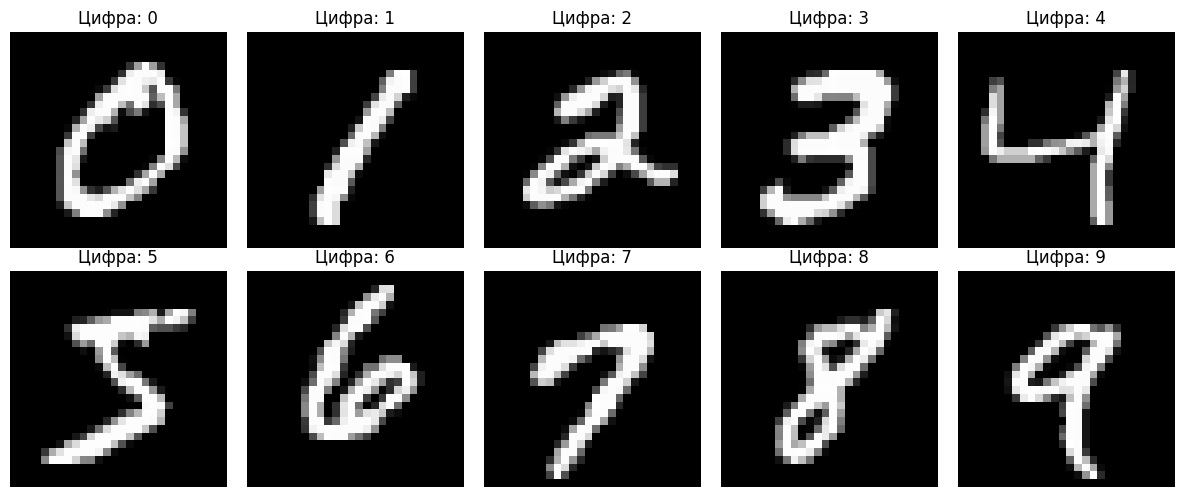

In [16]:
# По одному изображению на каждую цифру из обучающей выборки
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.flat):
    idx = (y_train == digit).nonzero(as_tuple=True)[0][0].item()
    ax.imshow(mnist_train.data[idx], cmap='gray')
    ax.set_title(f'Цифра: {digit}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Пункт 2. Построение и обучение нейронной сети

Сигнал проходит слои по формуле (методичка, формула 1):
$$S_j^{(n)} = \sum_{i \in I_{n-1}} w_{ij}^{(n)} y_i^{(n-1)}, \quad y_j^{(n)} = f\!\left(S_j^{(n)}\right)$$

In [17]:
def build_model(hidden1=128, hidden2=None, dropout_rate=0.0):
    """Сеть с 1 или 2 скрытыми слоями. hidden2=None → 1 скрытый слой."""
    layers_list = [nn.Linear(784, hidden1), nn.ReLU()]
    if dropout_rate > 0:
        layers_list.append(nn.Dropout(dropout_rate))
    if hidden2 is not None:
        layers_list += [nn.Linear(hidden1, hidden2), nn.ReLU()]
        if dropout_rate > 0:
            layers_list.append(nn.Dropout(dropout_rate))
        layers_list.append(nn.Linear(hidden2, 10))
    else:
        layers_list.append(nn.Linear(hidden1, 10))
    return nn.Sequential(*layers_list).to(DEVICE)

In [18]:
def make_loaders(X, y, batch_size=128, val_split=0.2):
    dataset = TensorDataset(X, y)
    n_val   = int(len(dataset) * val_split)
    train_ds, val_ds = random_split(dataset, [len(dataset) - n_val, n_val],
                                    generator=torch.Generator().manual_seed(42))
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            DataLoader(val_ds,   batch_size=batch_size))


def train_model(model, train_loader, val_loader, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward(); optimizer.step()
            t_loss    += loss.item() * len(y_b)
            t_correct += (out.argmax(1) == y_b).sum().item()
            t_total   += len(y_b)
        history['loss'].append(t_loss / t_total)
        history['acc'].append(t_correct / t_total)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out = model(X_b)
                v_loss    += criterion(out, y_b).item() * len(y_b)
                v_correct += (out.argmax(1) == y_b).sum().item()
                v_total   += len(y_b)
        history['val_loss'].append(v_loss / v_total)
        history['val_acc'].append(v_correct / v_total)

        print(f'Epoch {epoch:2d}/{epochs}  '
              f'loss={history["loss"][-1]:.4f}  acc={history["acc"][-1]:.4f}  '
              f'val_loss={history["val_loss"][-1]:.4f}  val_acc={history["val_acc"][-1]:.4f}')
    return history


def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['loss'],     label='train')
    ax1.plot(history['val_loss'], label='val')
    ax1.set_title(f'Loss  {title}'); ax1.set_xlabel('Эпоха'); ax1.legend()
    ax2.plot(history['acc'],     label='train')
    ax2.plot(history['val_acc'], label='val')
    ax2.set_title(f'Accuracy  {title}'); ax2.set_xlabel('Эпоха'); ax2.legend()
    plt.tight_layout(); plt.show()

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)
Параметров: 109,386
Epoch  1/15  loss=0.4714  acc=0.8694  val_loss=0.2587  val_acc=0.9250
Epoch  2/15  loss=0.1991  acc=0.9420  val_loss=0.1855  val_acc=0.9452
Epoch  3/15  loss=0.1417  acc=0.9586  val_loss=0.1518  val_acc=0.9563
Epoch  4/15  loss=0.1100  acc=0.9674  val_loss=0.1293  val_acc=0.9608
Epoch  5/15  loss=0.0876  acc=0.9739  val_loss=0.1147  val_acc=0.9656
Epoch  6/15  loss=0.0724  acc=0.9781  val_loss=0.1112  val_acc=0.9661
Epoch  7/15  loss=0.0590  acc=0.9823  val_loss=0.1081  val_acc=0.9677
Epoch  8/15  loss=0.0494  acc=0.9851  val_loss=0.1054  val_acc=0.9678
Epoch  9/15  loss=0.0426  acc=0.9874  val_loss=0.1066  val_acc=0.9683
Epoch 10/15  loss=0.0336  acc=0.9904  val_loss=0.0953  val_acc=0.9726
Epoch 11/15  loss=0.0292  acc=0.9914  val_loss=0.0996  val_ac

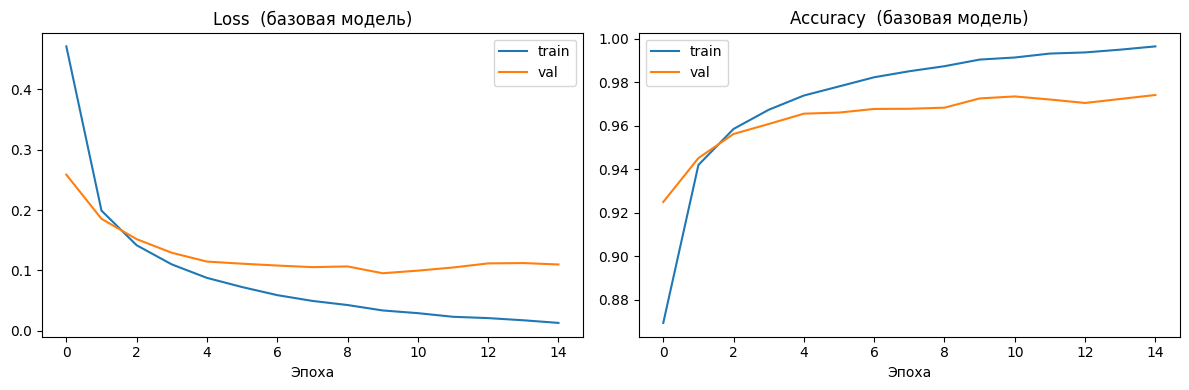

In [19]:
# Базовая модель: 2 скрытых слоя, без dropout
model = build_model(hidden1=128, hidden2=64)
print(model)
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

train_loader, val_loader = make_loaders(X_train, y_train, batch_size=128)
history = train_model(model, train_loader, val_loader, epochs=15)
plot_history(history, '(базовая модель)')

## Пункт 3. Оценка на тестовой выборке и матрица ошибок

In [20]:
def evaluate(model, X, y, batch_size=256):
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(X, y), batch_size=batch_size)
    model.eval()
    total_loss, preds = 0, []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            out = model(X_b)
            total_loss += criterion(out, y_b).item() * len(y_b)
            preds.append(out.argmax(1).cpu())
    y_pred = torch.cat(preds).numpy()
    loss   = total_loss / len(y)
    acc    = accuracy_score(y.numpy(), y_pred)
    return loss, acc, y_pred

test_loss, test_acc, y_pred = evaluate(model, X_test, y_test)
print(f'Test loss: {test_loss:.4f}  |  Test accuracy (evaluate): {test_acc:.4f}')

Test loss: 0.0903  |  Test accuracy (evaluate): 0.9788


Accuracy (confusion matrix): 0.9788


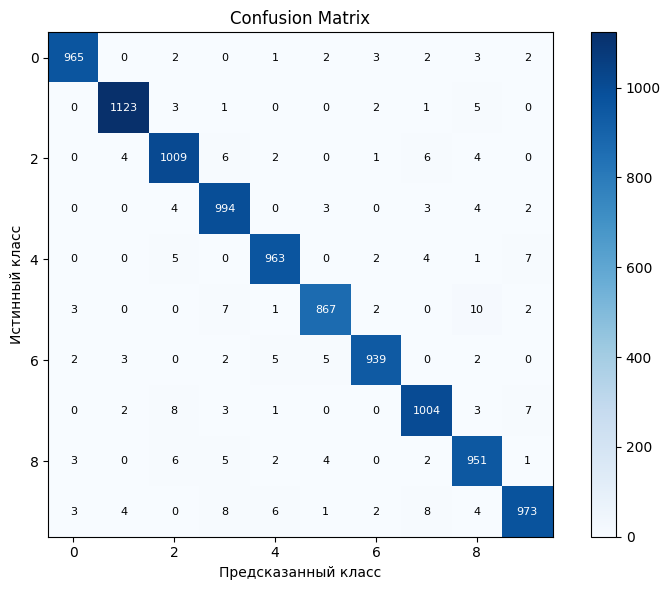

In [21]:
cm = confusion_matrix(y_test.numpy(), y_pred)
acc_cm = cm.diagonal().sum() / cm.sum()
print(f'Accuracy (confusion matrix): {acc_cm:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
ax.set_title('Confusion Matrix')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
plt.tight_layout(); plt.show()

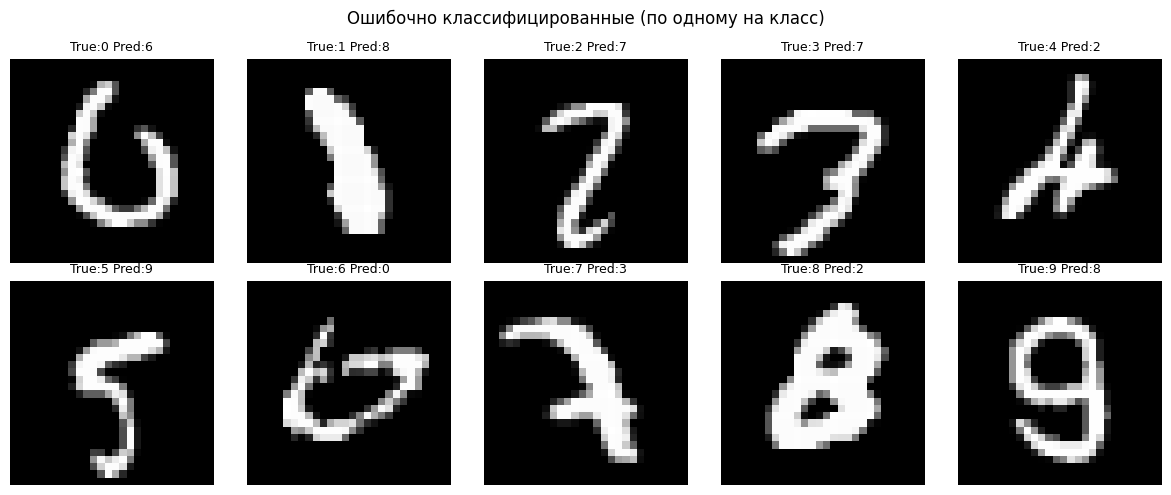

In [22]:
# По одному неверно классифицированному изображению на каждый класс
y_test_np = y_test.numpy()
errors_mask = (y_pred != y_test_np)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.flat):
    idxs = np.where((y_test_np == digit) & errors_mask)[0]
    if len(idxs) == 0:
        ax.axis('off'); continue
    idx = idxs[0]
    ax.imshow(mnist_test.data[idx], cmap='gray')
    ax.set_title(f'True:{digit} Pred:{y_pred[idx]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Ошибочно классифицированные (по одному на класс)')
plt.tight_layout(); plt.show()

## Пункт 4. Поиск оптимальных гиперпараметров (Grid Search)

Сеть с **одним** скрытым слоем. Параметры: число нейронов и `batch_size`.

In [23]:
# Используем часть данных для скорости
X_gs = X_train[:10000]
y_gs = y_train[:10000]

param_grid = {
    'hidden1':    [64, 128, 256],
    'batch_size': [64, 128, 256],
}

gs_results = []
for params in ParameterGrid(param_grid):
    fold_accs = []
    n = len(X_gs)
    for fold in range(3):  # 3-fold CV
        val_idx   = list(range(fold * n // 3, (fold + 1) * n // 3))
        train_idx = list(range(0, fold * n // 3)) + list(range((fold + 1) * n // 3, n))

        m    = build_model(hidden1=params['hidden1'])
        crit = nn.CrossEntropyLoss()
        opt  = optim.Adam(m.parameters())
        tl   = DataLoader(TensorDataset(X_gs[train_idx], y_gs[train_idx]),
                          batch_size=params['batch_size'], shuffle=True)
        m.train()
        for _ in range(10):
            for X_b, y_b in tl:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                opt.zero_grad(); crit(m(X_b), y_b).backward(); opt.step()

        _, acc, _ = evaluate(m, X_gs[val_idx], y_gs[val_idx])
        fold_accs.append(acc)

    mean_acc = np.mean(fold_accs)
    gs_results.append({**params, 'val_acc': mean_acc})
    print(f"hidden1={params['hidden1']:3d}  batch_size={params['batch_size']:3d}  val_acc={mean_acc:.4f}")

best = max(gs_results, key=lambda r: r['val_acc'])
print(f"\nЛучшие параметры: hidden1={best['hidden1']}, batch_size={best['batch_size']}, val_acc={best['val_acc']:.4f}")

hidden1= 64  batch_size= 64  val_acc=0.9262
hidden1=128  batch_size= 64  val_acc=0.9341
hidden1=256  batch_size= 64  val_acc=0.9395
hidden1= 64  batch_size=128  val_acc=0.9207
hidden1=128  batch_size=128  val_acc=0.9266
hidden1=256  batch_size=128  val_acc=0.9328
hidden1= 64  batch_size=256  val_acc=0.9130
hidden1=128  batch_size=256  val_acc=0.9169
hidden1=256  batch_size=256  val_acc=0.9277

Лучшие параметры: hidden1=256, batch_size=64, val_acc=0.9395


## Пункт 5. Аналитическое выражение числа весов и исследование конфигураций

**Число весовых коэффициентов** (с учётом смещений):

- **1 скрытый слой** ($h_1$ нейронов):
$$W_1(h_1) = (784 + 1)\cdot h_1 + (h_1 + 1)\cdot 10$$

- **2 скрытых слоя** ($h_1$, $h_2$ нейронов):
$$W_2(h_1, h_2) = (784 + 1)\cdot h_1 + (h_1 + 1)\cdot h_2 + (h_2 + 1)\cdot 10$$

Целевой диапазон: **70 000 – 100 000 весов**.

In [24]:
def weights_1hidden(h1):     return 785 * h1 + (h1 + 1) * 10
def weights_2hidden(h1, h2): return 785 * h1 + (h1 + 1) * h2 + (h2 + 1) * 10

configs = [
    dict(label='1 hidden  h1=90',           h1=90, h2=None, drop=0.0, bs=128),
    dict(label='1 hidden  h1=90  drop=0.3', h1=90, h2=None, drop=0.3, bs=128),
    dict(label='1 hidden  h1=90  bs=64',    h1=90, h2=None, drop=0.0, bs=64),
    dict(label='2 hidden  80+10',           h1=80, h2=10,   drop=0.0, bs=128),
    dict(label='2 hidden  80+10  drop=0.3', h1=80, h2=10,   drop=0.3, bs=128),
]

for c in configs:
    w = weights_1hidden(c['h1']) if c['h2'] is None else weights_2hidden(c['h1'], c['h2'])
    print(f"{c['label']:38s}  weights={w:,}")

1 hidden  h1=90                         weights=71,560
1 hidden  h1=90  drop=0.3               weights=71,560
1 hidden  h1=90  bs=64                  weights=71,560
2 hidden  80+10                         weights=63,720
2 hidden  80+10  drop=0.3               weights=63,720


In [25]:
EPOCHS = 20
results = {}

for c in configs:
    m = build_model(hidden1=c['h1'], hidden2=c['h2'], dropout_rate=c['drop'])
    tl, vl = make_loaders(X_train, y_train, batch_size=c['bs'])
    hist = train_model(m, tl, vl, epochs=EPOCHS)
    results[c['label']] = hist
    print(f"{c['label']:38s}  best_val_acc={max(hist['val_acc']):.4f}\n")

Epoch  1/20  loss=0.4858  acc=0.8757  val_loss=0.2858  val_acc=0.9203
Epoch  2/20  loss=0.2299  acc=0.9349  val_loss=0.2183  val_acc=0.9355
Epoch  3/20  loss=0.1767  acc=0.9502  val_loss=0.1803  val_acc=0.9485
Epoch  4/20  loss=0.1432  acc=0.9589  val_loss=0.1565  val_acc=0.9536
Epoch  5/20  loss=0.1211  acc=0.9651  val_loss=0.1444  val_acc=0.9573
Epoch  6/20  loss=0.1022  acc=0.9710  val_loss=0.1343  val_acc=0.9603
Epoch  7/20  loss=0.0891  acc=0.9747  val_loss=0.1240  val_acc=0.9634
Epoch  8/20  loss=0.0783  acc=0.9778  val_loss=0.1180  val_acc=0.9650
Epoch  9/20  loss=0.0691  acc=0.9806  val_loss=0.1093  val_acc=0.9674
Epoch 10/20  loss=0.0607  acc=0.9824  val_loss=0.1073  val_acc=0.9680
Epoch 11/20  loss=0.0527  acc=0.9851  val_loss=0.1056  val_acc=0.9697
Epoch 12/20  loss=0.0480  acc=0.9868  val_loss=0.1016  val_acc=0.9693
Epoch 13/20  loss=0.0419  acc=0.9887  val_loss=0.1046  val_acc=0.9699
Epoch 14/20  loss=0.0378  acc=0.9900  val_loss=0.0979  val_acc=0.9719
Epoch 15/20  loss=0.

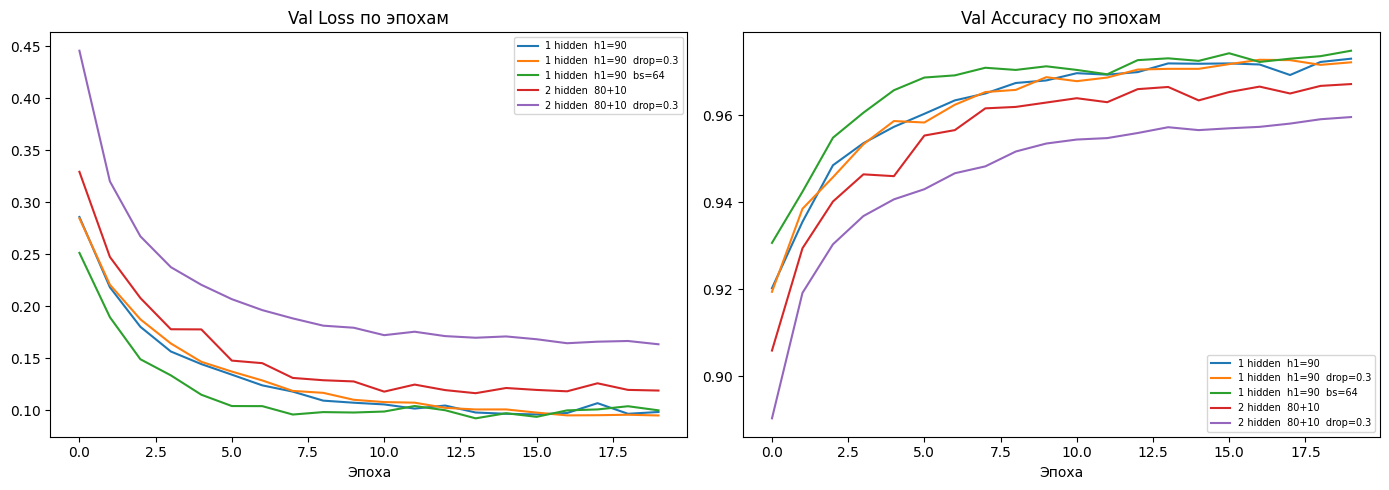

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for label, hist in results.items():
    ax1.plot(hist['val_loss'], label=label)
    ax2.plot(hist['val_acc'],  label=label)

ax1.set_title('Val Loss по эпохам'); ax1.set_xlabel('Эпоха'); ax1.legend(fontsize=7)
ax2.set_title('Val Accuracy по эпохам'); ax2.set_xlabel('Эпоха'); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

### Выводы

| Изменение | Наблюдаемый эффект |
|-----------|--------------------|
| Dropout | Замедляет сходимость, снижает переобучение |
| Меньший batch_size | Более шумный градиент, часто быстрее выходит на плато |
| 2 скрытых слоя vs 1 | При том же числе весов — меньше нейронов на слой, качество сопоставимо |

Оптимальные значения из Grid Search (пункт 4): см. ячейку выше.